# Titanic Survival Prediction with Logistic Regression

This project builds a machine learning model to predict whether a passenger survived the Titanic disaster based on demographic and ticket information.

The goal is to practice the full machine learning workflow, including:

- Data exploration
- Data cleaning
- Feature engineering
- Model training
- Model evaluation
- Model interpretation

The model used in this project is **logistic regression**, which is well suited for binary classification problems.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Dataset Overview

The dataset contains information about passengers aboard the Titanic. Each row represents a passenger, and the goal is to predict whether they survived.

Key features include:

- **Pclass** – Passenger class (1st, 2nd, 3rd)
- **Sex** – Gender of the passenger
- **Age** – Passenger age
- **SibSp** – Number of siblings/spouses aboard
- **Parch** – Number of parents/children aboard
- **Fare** – Ticket price
- **Embarked** – Port where the passenger boarded
- **Survived** – Target variable (1 = survived, 0 = did not survive)

This dataset is commonly used for introductory machine learning tasks because it requires both **data cleaning and feature engineering**.

In [65]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning

Before training a machine learning model, the dataset must be cleaned.

The Titanic dataset contains missing values, particularly in the **Age** column. Missing values are handled by replacing them with the **mean age** of the dataset.

This approach is known as **mean imputation**, and it allows the model to use all available rows during training.

## Feature Engineering

Feature engineering involves transforming raw data into more meaningful variables that help the model detect patterns.

Three engineered features were created:

### FamilySize
FamilySize combines the number of siblings/spouses and parents/children traveling with a passenger.

FamilySize = SibSp + Parch + 1

This captures the overall family structure of the passenger.

### IsAlone
IsAlone is a binary feature that indicates whether a passenger was traveling alone.

Passengers traveling alone may have had different survival outcomes than those traveling with family.

### Title
Passenger titles such as **Mr, Mrs, Miss, and Master** were extracted from the Name column using regular expressions.

Titles capture useful information about **gender, social status, and age group**, which are all important survival indicators.

In [66]:

mean = df['Age'].mean()
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

X = df.drop(["Survived","Cabin","Ticket","PassengerId","Name"], axis=1)
y = df["Survived"]


print(X)


     Pclass     Sex        Age  SibSp  Parch     Fare Embarked  FamilySize  \
0         3    male  22.000000      1      0   7.2500        S           2   
1         1  female  38.000000      1      0  71.2833        C           2   
2         3  female  26.000000      0      0   7.9250        S           1   
3         1  female  35.000000      1      0  53.1000        S           2   
4         3    male  35.000000      0      0   8.0500        S           1   
..      ...     ...        ...    ...    ...      ...      ...         ...   
886       2    male  27.000000      0      0  13.0000        S           1   
887       1  female  19.000000      0      0  30.0000        S           1   
888       3  female  29.699118      1      2  23.4500        S           4   
889       1    male  26.000000      0      0  30.0000        C           1   
890       3    male  32.000000      0      0   7.7500        Q           1   

     IsAlone  
0          0  
1          0  
2          1  
3  

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_327/781977290.py:5: SyntaxWarning: invalid escape sequence '\.'
  df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)


## Encoding Categorical Variables

Machine learning models require numerical inputs. Categorical variables such as **Sex, Embarked, and Title** must therefore be converted into numeric representations.

This project uses **one-hot encoding** with `pd.get_dummies()` to convert categorical variables into binary indicator columns.

In [67]:
X_encoded = pd.get_dummies(X, drop_first= True)

## Train/Test Split

To evaluate how well the model generalizes to unseen data, the dataset is split into two parts:

- **Training set (80%)** – used to train the model
- **Test set (20%)** – used to evaluate model performance

This ensures that the model is tested on data it has never seen before.

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size = 0.2,
    random_state = 42
)

## Feature Scaling

Feature scaling standardizes numeric variables so they have:

- mean = 0
- standard deviation = 1

This step is important for algorithms like **logistic regression**, which are sensitive to differences in feature magnitude.

Standardization ensures that features such as **Age and Fare** are on comparable scales.

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [70]:
X_encoded.isna().sum()

,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
FamilySize,0
IsAlone,0
Sex_male,0
Embarked_Q,0
Embarked_S,0


## Model Training

A **logistic regression model** is trained to predict passenger survival.

Logistic regression is commonly used for binary classification problems because it models the probability of an outcome using the **sigmoid function**.

In [71]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Model Evaluation

Model performance is evaluated using **accuracy**, which measures the proportion of correct predictions made on the test dataset.

After feature engineering and preprocessing, the model achieved an accuracy of approximately **81%** on the test set.

In [72]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


## Feature Importance

Logistic regression assigns a coefficient to each feature.

These coefficients represent how strongly each feature influences the model's prediction.

- **Positive coefficients** increase the probability of survival.
- **Negative coefficients** decrease the probability of survival.

The magnitude of the coefficient indicates how influential the feature is.

In [73]:
coeffs = pd.Series(model.coef_[0], index=X_encoded.columns)
print(coeffs.sort_values())

Sex_male     -1.246271
Pclass       -0.746402
Age          -0.395597
SibSp        -0.351581
IsAlone      -0.333702
FamilySize   -0.284120
Embarked_S   -0.169629
Parch        -0.081393
Embarked_Q   -0.022174
Fare          0.107438
dtype: float64


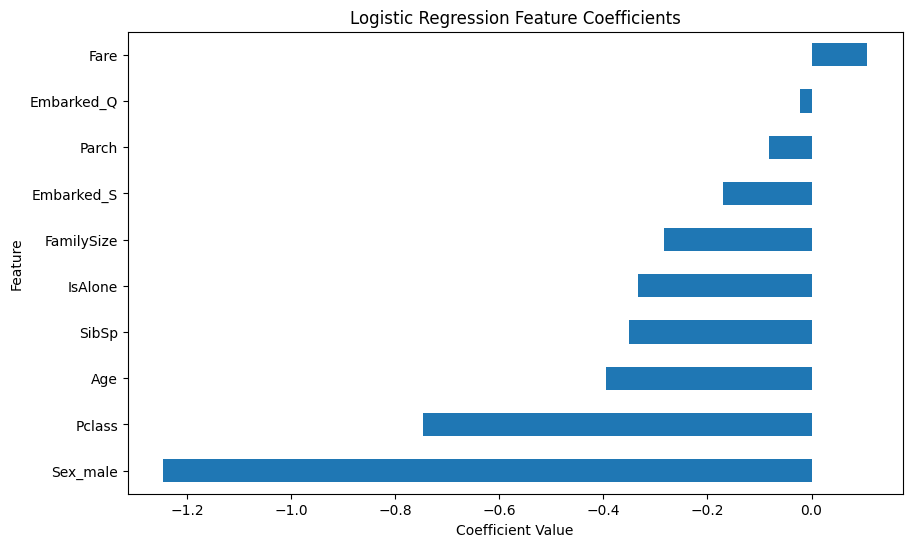

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

coeffs = pd.Series(model.coef_[0], index=X_encoded.columns)
coeffs = coeffs.sort_values()

plt.figure(figsize=(10, 6))
coeffs.plot(kind='barh')
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

## Interpreting Logistic Regression Feature Coefficients

The logistic regression model assigns a coefficient to each feature. These coefficients indicate how strongly each feature influences the predicted probability of survival.

- **Positive coefficients** increase the likelihood of survival.
- **Negative coefficients** decrease the likelihood of survival.

The magnitude of the coefficient represents the strength of the feature's influence.

Several patterns stand out:

**Gender (Sex_male)**  
Being male has the strongest negative coefficient, meaning male passengers were significantly less likely to survive. This aligns with historical accounts of the evacuation process prioritizing women and children.

**Passenger Class (Pclass)**  
Higher class numbers correspond to lower survival probabilities. Since third class passengers were located further from lifeboats, they were less likely to survive.

**Age**  
Older passengers had slightly lower survival probabilities, while younger passengers (especially children) were more likely to survive.

**Fare**  
Higher ticket prices slightly increased survival probability. This likely reflects the advantages associated with higher socioeconomic status and better cabin locations.

Overall, the model identifies **gender and passenger class as the most influential factors affecting survival**, which matches known historical patterns from the Titanic disaster.

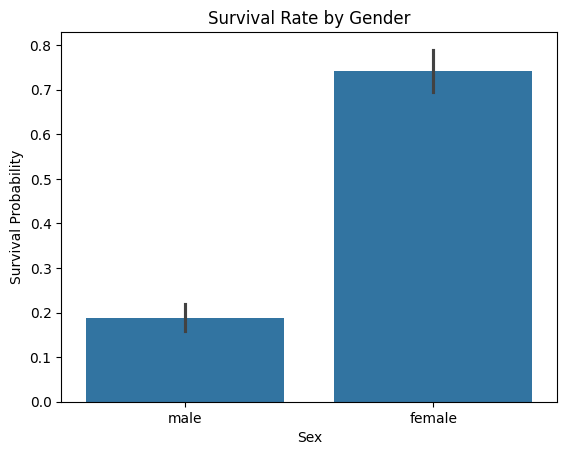

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.ylabel("Survival Probability")
plt.show()

## Interpreting the Survival Rate Plots

The exploratory data analysis plots help visualize how different features relate to survival outcomes.

Several clear patterns appear in the data:

**Gender**
Women had a significantly higher survival rate than men. This reflects the historical evacuation policy of "women and children first" during the Titanic disaster.

**Passenger Class**
Passengers in first class had much higher survival rates than those in third class. This likely reflects differences in cabin location, access to lifeboats, and overall socioeconomic status.

**Family Structure**
Passengers traveling with small families tended to survive more often than those traveling alone or in very large families. This pattern motivated the creation of the **FamilySize** and **IsAlone** features.

**Passenger Title**
Titles such as *Mrs*, *Miss*, and *Master* (which often represent women and children) had higher survival rates than *Mr*. Extracting titles from the Name column allowed the model to capture this important social pattern.

These observations guided the feature engineering process and helped improve model performance.

## Conclusion

This project demonstrates the full machine learning workflow using logistic regression on the Titanic dataset.

Key takeaways:

- Feature engineering significantly improved model performance.
- Gender and passenger class were the strongest predictors of survival.
- Logistic regression provided interpretable insights through feature coefficients.

The final model achieved approximately **81% accuracy**, showing that even simple models can perform well when supported by thoughtful feature engineering.